# DATA 1010 – Lab 1: Models, Errors, Loss, Optimization, and Learning

**Course:** DATA 1010 – Artificial Intelligence in Action  
**Lab 1 Theme:** How machines measure error, optimize models, and “learn” from data.  

You will work in **small groups** for this lab. One person should share their screen and run the notebook; everyone should be involved in discussion and decisions.

This lab has two main goals:

1. **Conceptual:** Understand how we measure error, what “loss” means, and how optimization finds better models.
2. **Practical:** Get comfortable running and modifying code in Google Colab.

You will record your answers to lab questions on a **separate handout or LMS assignment**, *not* inside this notebook.


## AI Use for This Lab

You **may** use AI tools (e.g., ChatGPT, Copilot) to:

- Help you understand Python error messages.
- Explain what a particular line of code is doing.
- Suggest ways to debug when something breaks.

You **may not** use AI tools to:

- Generate full answers to the conceptual questions on your lab handout.
- Choose parameter values for you (e.g., “what slope should I use?”).
- Run the entire lab for you without group discussion.

If you use an AI tool, note **what you used** and **how you used it** in your lab writeup.




---



---



---


# The Prelab
## Complete sections 0 and 1 before class!

## 0. Getting Started in Google Colab

Google Colab lets you run Python code in your browser without installing anything.

A **cell** is a block of code or text. To run a code cell:

1. Click on the cell.
2. Press `Shift+Enter` (or click the ▶ button on the left).

Let’s test that your Colab environment works.


In [25]:
# Run this cell to confirm your Colab environment works.
print("Colab is running! Edit this message and re-run the cell.")


Colab is running! Edit this message and re-run the cell.


### 0.1 Simple Python Variables

In this course, we’ll often change **parameters** (numbers that control models) and watch how the output changes.

Run the code cell below, then:

1. Change the values of `x` and `y`.
2. Run the cell again.
3. Watch how `z` changes.

On your lab handout, you’ll answer questions about what you observe.


In [26]:
# Change x and y, then run this cell multiple times.
x = 3
y = 5

z = 2 * x + y
print(f"x = {x}, y = {y}, z = 2 * x + y = {z}")


x = 3, y = 5, z = 2 * x + y = 11


### 0.2 Lists, Loops, and a Simple Plot

Later in the lab, we’ll work with **many data points** at once.
This example shows:

- a list of x-values,
- computing y-values with a simple rule,
- and plotting them.

You don’t need to memorize the syntax; just get used to the idea that:

> Python can compute values for many x’s and plot them all at once.


x-values: [0, 1, 2, 3, 4]
y-values: [0, 2, 4, 6, 8]


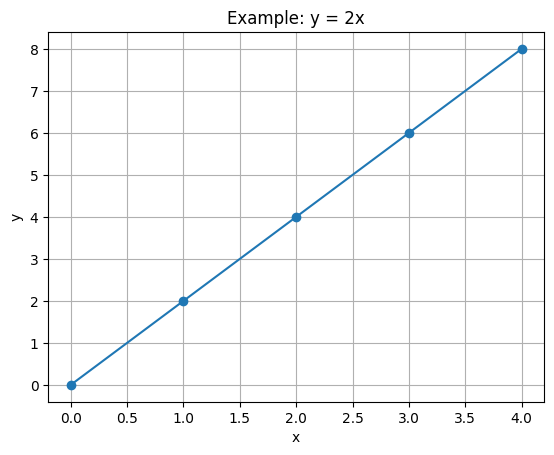

In [27]:
import matplotlib.pyplot as plt

xs = [0, 1, 2, 3, 4]
ys = [2 * x for x in xs]  # y = 2x

print("x-values:", xs)
print("y-values:", ys)

plt.figure()
plt.plot(xs, ys, marker='o')
plt.title("Example: y = 2x")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


## 1. Group Code and Randomized Experiments

Different groups will see **different data and hidden functions**, but your group will see the **same** setup every time you re-run the notebook.

To do this, we’ll use a **group code**:

- Choose an integer as a group code (e.g., 1234).
- Enter it in the cell below.
- This code controls the random number generator.
- At the end of the lab, we’ll reveal the exact parameters for your group, and you’ll use them in your writeup.


In [28]:
import numpy as np

group_code = int(input("Enter your group code (integer): "))

np.random.seed(group_code)
print(f"Random seed set using group code: {group_code}")


Enter your group code (integer): 123
Random seed set using group code: 123


In [29]:
import matplotlib.pyplot as plt

# Generate random "true" line parameters for your group
true_m = np.random.uniform(-3, 3)
true_b = np.random.uniform(-5, 5)

# Generate data points around the true line with noise
x = np.linspace(-5, 5, 25)
noise = np.random.normal(0, 1.0, size=len(x))
y = true_m * x + true_b + noise

def sse(y_true, y_pred):
    """Sum of squared errors (global loss)."""
    return np.sum((y_true - y_pred)**2)

print("Data for line fitting has been generated for your group.")


Data for line fitting has been generated for your group.


## What Do We Mean by a *Model*?

In this course, the word **model** has a very specific meaning.

A **model** is a rule, formula, or pattern that **makes predictions** based on input values.  A model isn't "reality,", but it attempts to closely capture how a set of data behaves.

### Examples of simple models:

- A straight line:  
  `prediction = m * x + b`
- A rule like “every hour the temperature drops by 2 degrees.”
- A computer program that takes an image and predicts what object is in it.

A model has **parameters** — numbers that control how it behaves.

- For a line, the parameters are the **slope** `m` and **intercept** `b`.
- In more complicated models (like neural networks), there can be millions of parameters.

### What models do

A model:

1. **Takes input**  
   (for example, a value of `x`)

2. **Produces a prediction**  
   (for example, a predicted value of `y`)

3. **Can be adjusted**  
   by changing its parameters

### Why we adjust models

If a model’s predictions do not match the data very well, we adjust the parameters to make it better.

But the model does *not* know whether its guesses look “right.”  
It only receives one piece of information: **the total error** (loss) based on the differences between prediction and data.

This is why we spend so much time defining error and loss — these numbers tell the model how to improve.

### In short:

A **model** is a system that:

- makes predictions,
- depends on adjustable parameters, and
- is improved by reducing its total error on data.

This idea is the foundation of both simple curve fitting **and** modern AI systems.


## Understanding Error and Total Error (Loss)

Before we start fitting models, we need a clear idea of **what “error” means**.

### **1.1 Error at a Single Data Point**

Suppose we have:

- a true value from data: `actual`,  
- a predicted value from our model: `predicted`.

The **error** at that point is simply the difference:


Positive error means the model predicted too *low*.  
Negative error means the model predicted too *high*.

### **1.2 Why We Don’t Just Add These Errors**

If we add all the raw errors for a dataset, something bad happens:

- some errors are positive,
- some are negative,
- and they can cancel each other out even if the model is doing a terrible job.

Example:  
If one point is off by +5 and another is off by –5, the total would look like “0”,  
even though both points are badly wrong.

We don’t want cancellations — we want a measure of **how wrong** the model is overall.

### **1.3 Squaring Errors to Make Them All Positive**

To fix this, we **square** each individual error:

squared_error = (actual – predicted)^2


This has three important effects:

- All errors become **positive**, so nothing cancels out.
- Larger mistakes become **much more noticeable** (a big miss matters more than a small one).
- The math works out nicely later when we do optimization.

### **1.4 Total Error (also called Loss)**

To measure how well a model fits *all* the data points, we combine the squared errors:
total_error = squared_error_1 + squared_error_2 + squared_error_3 + ...


This is often called the **loss**.

A **good** model has a **small** total error.  
A **bad** model has a **large** total error.

### **1.5 Why We Use Total Error in Optimization**

When we’re adjusting model parameters (like slope and intercept), the only thing the computer “looks at” is the **total error**. It doesn’t see the data points or the line shape the way a person does.

The optimizer tries different values, checks the total error, and tries to reduce that number.  

This is why understanding *how* we compute error is essential — it becomes the entire “signal” that guides learning.





---



---



---


# The in class lab
## Work on the cells 2 through 6 with in your lab group

## 2. Error and Loss – Global Error with Visible Line

First, we’ll **show** you the true line and compute its global error (loss) for your noisy data.

- Each point has some **error**: the vertical distance between the point and the line.
- The **global error** (or **loss**) is the sum of the squared errors across all points.

Run the next cell and look at:

- The scatter of data points.
- The true line.
- The printed **Sum of Squared Errors (SSE)**.

👉 On your handout, answer:

**Q1.** In your own words, what does “global error” or “loss” measure in this plot?  
**Q2.** If we changed the slope or intercept of the line, how would that change the loss?


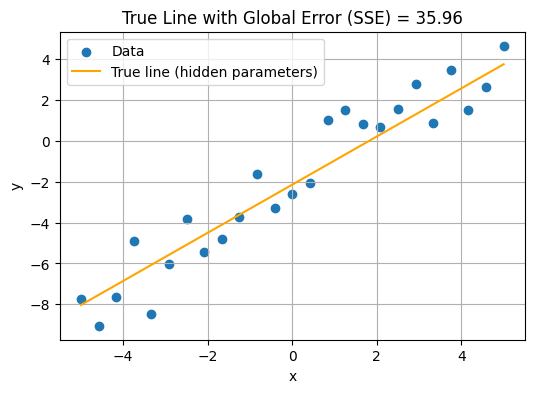

True line parameters (hidden from students for now): m = 1.179, b = -2.139
Global error (SSE) = 35.96
Instructor note: You may want to hide this output when using in class.


In [31]:
# Plot the data and the true line, and compute the global error.

y_true_line = true_m * x + true_b
total_loss = sse(y, y_true_line)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, label='Data')
plt.plot(x, y_true_line, label=f'True line (hidden parameters)', color='orange')
plt.title(f"True Line with Global Error (SSE) = {total_loss:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

print(f"True line parameters (hidden from students for now): m = {true_m:.3f}, b = {true_b:.3f}")
print(f"Global error (SSE) = {total_loss:.2f}")
print("Instructor note: You may want to hide this output when using in class.")


## 3. Error and Loss – Exploring Fits with a Hidden True Line

Now we’ll **hide** the true line and let you experiment with your own line.

You will:

- Use sliders to choose a **slope** and **intercept**.
- See your line plotted with the data.
- See the **global error (SSE)** for your line.
- See **residuals**: vertical lines showing the error at each point.
- Get **“warmer/colder”** feedback comparing your current error to your previous one.
- See a **history table** of your recent attempts.

👉 On your handout, you will answer questions about:

- How local (point-wise) errors relate to global error.
- Whether you can have a small global error even if some points have large errors.


In [32]:
import pandas as pd
from ipywidgets import interact, FloatSlider, Checkbox

# Reset attempt history each time this cell is run
attempt_history = []

def plot_guess(m, b, show_residuals=True):
    """Plot the user's guessed line, compute SSE, and record history."""
    global attempt_history

    y_pred = m * x + b
    loss = sse(y, y_pred)

    prev_loss = attempt_history[-1]["loss"] if attempt_history else None
    attempt_history.append({"m": m, "b": b, "loss": loss})

    # Plot data and guessed line
    plt.figure(figsize=(7, 4))
    plt.scatter(x, y, label="Data")
    plt.plot(x, y_pred, label=f"Your line: y = {m:.2f}x + {b:.2f}", color='green')

    # Plot residuals if requested
    if show_residuals:
        for xi, yi, ypi in zip(x, y, y_pred):
            plt.plot([xi, xi], [yi, ypi], linestyle='--', alpha=0.6)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Your Global Error (SSE) = {loss:.2f}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Warm/colder feedback
    if prev_loss is not None:
        if loss < prev_loss:
            print("Feedback: 🔥 Warmer (your global error decreased).")
        elif loss > prev_loss:
            print("Feedback: 🧊 Colder (your global error increased).")
        else:
            print("Feedback: No change in global error.")

    # Show last few attempts
    df = pd.DataFrame(attempt_history)
    print("Recent attempts:")
    display(df.tail(5))

interact(
    plot_guess,
    m = FloatSlider(value=0.0, min=-5, max=5, step=0.1, description="Slope m"),
    b = FloatSlider(value=0.0, min=-5, max=5, step=0.1, description="Intercept b"),
    show_residuals = Checkbox(value=True, description="Show residuals"),
);


interactive(children=(FloatSlider(value=0.0, description='Slope m', max=5.0, min=-5.0), FloatSlider(value=0.0,…

### 3.1 Local vs Global Error – Reflection

Use the sliders for a while and try to make the **global error (SSE)** as small as you can.

👉 On your handout, answer:

**Q3.** How do the residual lines (the dashed vertical lines) help you understand the **local error** at each point?  

**Q4.** Can you make the global error small even if a few points still have relatively large errors? Describe a situation where this happens and why.  

**Q5.** Suppose you add one very extreme outlier point far away from the others. Predict how this will affect the best-fit line and the global error.


## 3.2 Optimizing Only on Global Error (MSE) – Parameter Space Game

In the last section, you could see both:

- the **data points**,
- and the **line** you were fitting,

plus local residuals and the global error (SSE).

In this section, we will **hide everything except the global error**.

We will work in **parameter space**:

- The horizontal axis will be the slope **m**.
- The vertical axis will be the intercept **b**.
- Each guess (m, b) corresponds to a line `y = m x + b` that could be fit to the data.

For each guess, the computer will:

1. Compute the **Mean Squared Error (MSE)** between your line and the data.
2. Add your guess (m, b, MSE) to a **table**.
3. Plot your guesses as **points in the (m, b) plane**, with the **color** of the most recent point showing its MSE (lower is better).

You will **not** see:

- the underlying data points,
- the true line,
- or the full error surface,

until the very end.

**Your goal:**  
Use only the global error (MSE) and the history of your guesses to move toward a good fit (a small MSE). This is directly analogous to what optimization algorithms do in machine learning: they “see” only the loss and adjust parameters to reduce it.

When your group feels you have done enough exploration, click the **“Done”** button. Then the notebook will reveal:

- a **color map** of MSE over the (m, b) grid,
- your guess history overlaid,
- and the location of the actual minimum.




In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, Button, Output, HBox, VBox
from IPython.display import display

# Make sure we have x, y, and sse or compute_mse defined earlier.

# Generate random "true" line parameters for your group,
# kept away from the slider edges.
true_m = np.random.uniform(-3.0, 3.0)
true_b = np.random.uniform(-3.0, 3.0)

# Range of m and b to explore
M_MIN, M_MAX = -5.0, 5.0
B_MIN, B_MAX = -5.0, 5.0

# Widgets: sliders for m and b, buttons, and output areas
m_slider = FloatSlider(
    description="m (slope)",
    min=M_MIN,
    max=M_MAX,
    step=0.1,
    value=0.0,
    continuous_update=False
)

b_slider = FloatSlider(
    description="b (intercept)",
    min=B_MIN,
    max=B_MAX,
    step=0.1,
    value=0.0,
    continuous_update=False
)

submit_button = Button(
    description="Submit guess",
    button_style="info"
)

done_button = Button(
    description="Done",
    button_style="success"
)

out_game = Output()
out_reveal = Output()

# Store guesses as a list of dicts
mse_history = []

def compute_mse(m, b):
    """Mean squared error for line y = m x + b against the data."""
    y_pred = m * x + b
    return float(np.mean((y - y_pred) ** 2))

def on_submit_clicked(b_widget):
    """Record a guess and update the table + (m,b) plot with colors = MSE."""
    m_guess = m_slider.value
    b_guess = b_slider.value
    mse_val = compute_mse(m_guess, b_guess)

    mse_history.append({
        "attempt": len(mse_history) + 1,
        "m": m_guess,
        "b": b_guess,
        "MSE": mse_val
    })

    df = pd.DataFrame(mse_history)

    with out_game:
        out_game.clear_output(wait=True)
        print("Parameter-space optimization: your goal is to find (m, b) with a small MSE.")
        print("You will only see global error (MSE), not the underlying data or line.\n")

        # Show recent guesses in a table
        print("Recent guesses:")
        display(df.tail(10))

        # Plot guesses in (m, b) space with colors tied to each point's MSE
        plt.figure(figsize=(7, 5))

        ms = df["m"].values
        bs = df["b"].values
        mses = df["MSE"].values

        # Color all points by MSE so color always reflects quality
        sc = plt.scatter(ms, bs,
                         c=mses,
                         cmap="viridis",
                         s=80,
                         edgecolor="black",
                         label="Your guesses")

        # Highlight the current best guess with a special marker
        best_idx = df["MSE"].idxmin()
        best_row = df.loc[best_idx]
        plt.scatter([best_row["m"]], [best_row["b"]],
                    marker="*",
                    s=200,
                    color="red",
                    edgecolor="black",
                    label="Best guess so far")

        plt.xlabel("m (slope)")
        plt.ylabel("b (intercept)")
        plt.xlim(M_MIN, M_MAX)
        plt.ylim(B_MIN, B_MAX)
        plt.title("Your guesses in (m, b) space\nColor = MSE (lower is better)")
        cbar = plt.colorbar(sc)
        cbar.set_label("MSE")
        plt.grid(True)
        plt.legend()
        plt.show()

def on_done_clicked(b_widget):
    """Show the full MSE landscape, global minimum, and the group's path."""
    submit_button.disabled = True
    done_button.disabled = True
    m_slider.disabled = True
    b_slider.disabled = True

    if not mse_history:
        with out_reveal:
            out_reveal.clear_output()
            print("No guesses were made. Nothing to reveal.")
        return

    # Compute MSE over a grid in (m, b) space
    m_vals = np.linspace(M_MIN, M_MAX, 80)
    b_vals = np.linspace(B_MIN, B_MAX, 80)
    M, B = np.meshgrid(m_vals, b_vals)
    mse_grid = np.zeros_like(M)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            mse_grid[i, j] = compute_mse(M[i, j], B[i, j])

    # Find approximate global minimum on the grid
    flat_index = np.argmin(mse_grid)
    i_min, j_min = np.unravel_index(flat_index, mse_grid.shape)
    m_min = M[i_min, j_min]
    b_min = B[i_min, j_min]

    # Compute least-squares solution from the data
    A = np.vstack([x, np.ones_like(x)]).T
    m_ls, b_ls = np.linalg.lstsq(A, y, rcond=None)[0]

    df = pd.DataFrame(mse_history)
    best_idx = df["MSE"].idxmin()
    best_guess = df.loc[best_idx]

    with out_reveal:
        out_reveal.clear_output()
        print("MSE landscape in (m, b) space with your guesses and the minima:\n")

        plt.figure(figsize=(8, 6))
        cs = plt.contourf(M, B, mse_grid, levels=30, cmap="viridis")
        cbar = plt.colorbar(cs)
        cbar.set_label("MSE")

        # Overlay all guesses, colored by their MSE
        sc2 = plt.scatter(df["m"], df["b"],
                          c=df["MSE"],
                          cmap="viridis",
                          s=80,
                          edgecolor="black",
                          label="Your guesses")

        # Highlight your best guess
        plt.scatter([best_guess["m"]], [best_guess["b"]],
                    color="red", marker="*",
                    s=200, edgecolor="black",
                    label="Your best guess")

        # Overlay approximate global minimum on grid
        plt.scatter([m_min], [b_min], color="white", marker="o",
                    s=150, edgecolor="black",
                    label="Grid global minimum")

        # Overlay least-squares solution
        plt.scatter([m_ls], [b_ls], color="yellow", marker="X",
                    s=150, edgecolor="black",
                    label="Least-squares solution")

        plt.xlabel("m (slope)")
        plt.ylabel("b (intercept)")
        plt.xlim(M_MIN, M_MAX)
        plt.ylim(B_MIN, B_MAX)
        plt.title("MSE Landscape and Your Path in (m, b) Space")
        plt.legend()
        plt.grid(True)
        plt.show()

        print(f"Approximate global minimum on grid: m ≈ {m_min:.3f}, b ≈ {b_min:.3f}")
        print(f"Least-squares solution from data:    m ≈ {m_ls:.3f}, b ≈ {b_ls:.3f}")
        print(f"True parameters used for your data:  m_true = {true_m:.3f}, b_true = {true_b:.3f}")
        print("\nYour best guess based on MSE only:")
        display(best_guess)

submit_button.on_click(on_submit_clicked)
done_button.on_click(on_done_clicked)

print("Parameter-space MSE game:")
print(f"- Adjust m and b using the sliders in ranges [{M_MIN}, {M_MAX}] and [{B_MIN}, {B_MAX}].")
print("- Click 'Submit guess' to record a new (m, b) and see its MSE.")
print("- Colors always represent MSE, so darker/“cooler” colors are better (lower error).")
print("- When your group is satisfied, click 'Done' to reveal the full MSE landscape.\n")

display(VBox([
    HBox([m_slider, b_slider]),
    HBox([submit_button, done_button]),
    out_game,
    out_reveal
]))


Parameter-space MSE game:
- Adjust m and b using the sliders in ranges [-5.0, 5.0] and [-5.0, 5.0].
- Click 'Submit guess' to record a new (m, b) and see its MSE.
- Colors always represent MSE, so darker/“cooler” colors are better (lower error).
- When your group is satisfied, click 'Done' to reveal the full MSE landscape.



### 3.3 Reflection on Optimizing Global Error

In this game, you only saw the **global error (MSE)** and the history of your guesses in parameter space.

👉 On your handout, answer:

**Q6.** Describe how your guesses for (m, b) moved over time. Did you follow any systematic strategy (e.g., “move m a bit, then adjust b”, or “search in a grid”, etc.)?

**Q7.** Look at the MSE landscape plot. How close was your best guess to:
- the approximate global minimum on the grid, and  
- the least-squares solution from the data?

What does this tell you about optimizing *only* based on the global error?

**Q8.** In our earlier line-fitting exercise, you could see the data, the line, and the residuals. In this game, you only saw the MSE. How is this situation similar to how many machine learning models are trained, where the algorithm only sees a **loss value** and not the “right answer” in a human-readable way?


## 4. Optimization Game with a Hidden Function (Bounded, No Function Plot)

In this game, there is a **hidden function** `f(x)`.  This is not just a linear curve, but a more complicated function.  Finding the minimum value doesn't depend on just fitting a line.  We can use the same ideas to fit **ANY** curve.

- You will choose values of **x** in a given range (for this lab: from **-10 to 10**).
- The computer will tell you **f(x)** at your chosen x.
- Your goal is to find an x that gives a **small** value of f(x) (ideally near the minimum).

Important:

- You will **not** see the full curve of the function, only your guesses.
- The valid range is **-10 ≤ x ≤ 10**. Values outside this range will be rejected.
- Type **999** to stop when you are done experimenting.

The notebook will keep a running **scatter plot** of your guesses and a **table** of recent attempts, updating them in place as you go.  You should use the table and the graph to get the best value.


In [ ]:
# Generate random parameters for a hidden 1D function based on the group seed

a = np.random.uniform(0.5, 2.0)       # curvature (positive so it's a bowl)
b_param = np.random.uniform(-4, 4)    # x-location of the minimum
c_param = np.random.uniform(-10, 10)  # minimum value

def hidden_func(x_val):
    """Hidden 1D function we are trying to minimize."""
    return a * (x_val - b_param)**2 + c_param

# Domain for visualization
x_grid = np.linspace(-10, 10, 400)
y_grid = hidden_func(x_grid)

print("Hidden function has been defined for your group.")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, Button, Output, VBox
from IPython.display import display

# History of guesses for this game
opt_history = []

# Bounds for x that we tell students about
X_MIN, X_MAX = -10.0, 10.0

# Widgets: slider for x, button to submit, output area for plot/table
x_slider = FloatSlider(
    description="x guess",
    min=X_MIN,
    max=X_MAX,
    step=0.2,
    value=0.0,
    continuous_update=False
)

submit_button = Button(
    description="Try this x",
    button_style="",  # can be 'success', 'info', 'warning', 'danger'
)

out = Output()

def record_and_update_display(x_guess):
    """Evaluate hidden_func at x_guess, record it, and update plot + table."""
    global opt_history

    y_guess = hidden_func(x_guess)
    prev = opt_history[-1] if opt_history else None

    opt_history.append({
        "attempt": len(opt_history) + 1,
        "x": x_guess,
        "f(x)": y_guess
    })

    with out:
        out.clear_output(wait=True)

        print(f"Optimization game: x is restricted to [{X_MIN}, {X_MAX}].")
        print("Use the slider to choose x, then click 'Try this x'.\n")

        # Plot only the guesses (no underlying function)
        plt.figure(figsize=(7, 4))

        xs = [g["x"] for g in opt_history]
        ys = [g["f(x)"] for g in opt_history]

        plt.scatter(xs, ys, label="Your guesses", zorder=3)
        plt.scatter([xs[-1]], [ys[-1]], color="red", zorder=4, label="Current guess")

        plt.xlabel("x (your chosen input)")
        plt.ylabel("f(x) (value returned by the hidden function)")
        plt.title("Your guesses on the hidden function (no curve shown)")
        plt.grid(True)
        plt.legend()
        plt.show()

        # Warm/colder feedback
        if prev is not None:
            if y_guess < prev["f(x)"]:
                print("Feedback: 🔥 Warmer (your f(x) decreased).")
            elif y_guess > prev["f(x)"]:
                print("Feedback: 🧊 Colder (your f(x) increased).")
            else:
                print("Feedback: No change in f(x).")

        # Show a small table of recent guesses
        df = pd.DataFrame(opt_history)
        print("\nRecent guesses:")
        display(df.tail(8))

def on_submit_clicked(b):
    x_guess = x_slider.value
    record_and_update_display(x_guess)

submit_button.on_click(on_submit_clicked)

print("Optimization game: try to find an x that makes f(x) as small as possible.")
print(f"x is restricted to [{X_MIN}, {X_MAX}].")
print("Move the slider, then click 'Try this x' each time you want a new guess.\n")

display(VBox([x_slider, submit_button, out]))


### 4.1 Optimization Reflection

After you’ve tried several values of x and looked at your plots and history:

👉 On your handout, answer:

**Q9.** What strategies did your group use to choose new values of x within the allowed range?  

**Q10.** How did the “warmer/colder” feedback influence your choices?  

**Q11.** Imagine that even the scatter plot of your guesses was hidden, and you only saw the table of (x, f(x)). Would you still be able to find a good minimum? How?


In [ ]:
print("=== Instructor Reveal – Line Fitting ===")
print(f"True line parameters for your group:")
print(f"  m (slope)     = {true_m:.3f}")
print(f"  b (intercept) = {true_b:.3f}")
print()

print("=== Instructor Reveal – Hidden Function ===")
print("Your hidden function had the form:")
print(f"  f(x) = {a:.3f} * (x - {b_param:.3f})^2 + {c_param:.3f}")
print()
print(f"The exact minimum is at:")
print(f"  x = {b_param:.3f}, f(x) = {c_param:.3f}")
print()

print("Record these values on your lab handout for your writeup.")


## 5. Finding a Mountain Peak – Optimization Beyond Line Fitting

So far, our optimization examples involved **fitting a line** to data:

- Parameters: slope *m* and intercept *b*.
- Goal: choose (*m*, *b*) to make the **global error** (loss) small.

But optimization and learning are **not just about line fitting**.

In many problems, we want to:

- **maximize** something (e.g., profit, altitude, reward), or  
- **minimize** something (e.g., cost, time, error),

over a space of possible choices.

In this activity, imagine you are exploring a **mountain range**:

- For any coordinate *(x, y)*, there is an **altitude** `h(x, y)`.
- You can “visit” points in the landscape and measure the altitude, but:
  - you **cannot** see the whole mountain range,
  - you only see the locations you choose and their altitudes.

However, the landscape is tricky:

- There is **not just one peak**, but **several peaks**.
- Some peaks are higher than others.

Your job is to use **samples of altitude** to:

- search for high regions,
- try to find the **highest peak** you can,
- and notice the difference between **local peaks** and a **global peak**.

At the end, we’ll reveal the full mountain landscape and compare:

- your best-found peak,
- the true global peak,
- and the other local peaks you might have visited.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, Button, Output, HBox, VBox
from IPython.display import display

# ------------------------------------------------------------
# 1. Define the hidden mountain landscape (multiple peaks)
# ------------------------------------------------------------

# Assume np.random.seed(group_code) has already been called earlier.
# We generate a sum of Gaussian bumps to create several peaks.

X_MIN, X_MAX = -5.0, 5.0
Y_MIN, Y_MAX = -5.0, 5.0

num_peaks = np.random.randint(3, 6)  # between 3 and 5 peaks

peak_centers = []
peak_heights = []
peak_widths = []

for _ in range(num_peaks):
    cx = np.random.uniform(-3.0, 3.0)
    cy = np.random.uniform(-3.0, 3.0)
    height = np.random.uniform(1.0, 5.0)
    width = np.random.uniform(0.6, 1.5)

    peak_centers.append((cx, cy))
    peak_heights.append(height)
    peak_widths.append(width)

def mountain_height(x, y):
    """Hidden mountain landscape: sum of Gaussian peaks."""
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.zeros_like(x, dtype=float)
    for (cx, cy), h, w in zip(peak_centers, peak_heights, peak_widths):
        z += h * np.exp(-(((x - cx)**2 + (y - cy)**2) / (2 * w**2)))
    return z

print(f"Hidden mountain landscape created with {num_peaks} peaks (kept secret from students).")

# ------------------------------------------------------------
# 2. Widgets and state for interactive sampling
# ------------------------------------------------------------

x_slider_2d = FloatSlider(
    description="x",
    min=X_MIN,
    max=X_MAX,
    step=0.2,
    value=0.0,
    continuous_update=False
)

y_slider_2d = FloatSlider(
    description="y",
    min=Y_MIN,
    max=Y_MAX,
    step=0.2,
    value=0.0,
    continuous_update=False
)

sample_button = Button(
    description="Measure altitude",
    button_style="info"
)

done_button_2d = Button(
    description="Done",
    button_style="success"
)

out_2d_game = Output()
out_2d_reveal = Output()

# Store samples as a list of dicts: {attempt, x, y, height}
samples_2d = []

def on_sample_clicked(b_widget):
    """Record a sample (x, y, height) and update the plot + table."""
    x_guess = x_slider_2d.value
    y_guess = y_slider_2d.value
    h_val = float(mountain_height(x_guess, y_guess))

    samples_2d.append({
        "attempt": len(samples_2d) + 1,
        "x": x_guess,
        "y": y_guess,
        "height": h_val
    })

    df = pd.DataFrame(samples_2d)

    with out_2d_game:
        out_2d_game.clear_output(wait=True)
        print("Mountain optimization game:")
        print(f"- Choose (x, y) within [{X_MIN}, {X_MAX}] x [{Y_MIN}, {Y_MAX}].")
        print("- Click 'Measure altitude' to see the height at that point.")
        print("- You only see the sampled points, not the whole mountain.\n")

        print("Recent samples:")
        display(df.tail(10))

        # Plot sampled points in (x, y), colored by altitude
        plt.figure(figsize=(7, 5))

        xs = df["x"].values
        ys = df["y"].values
        hs = df["height"].values

        sc = plt.scatter(xs, ys, c=hs, cmap="plasma", s=80, edgecolor="black")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.xlim(X_MIN, X_MAX)
        plt.ylim(Y_MIN, Y_MAX)
        plt.title("Your sampled locations (color = altitude)")
        cbar = plt.colorbar(sc)
        cbar.set_label("Altitude")
        plt.grid(True)
        plt.show()

        # Highlight the current best sample
        best_idx = df["height"].idxmax()
        best_row = df.loc[best_idx]
        print(f"Current best sample: attempt {int(best_row['attempt'])}, "
              f"x = {best_row['x']:.2f}, y = {best_row['y']:.2f}, "
              f"height = {best_row['height']:.3f}")

def on_done_clicked_2d(b_widget):
    """Reveal the full landscape, global peak, and the group's best sample."""
    sample_button.disabled = True
    done_button_2d.disabled = True
    x_slider_2d.disabled = True
    y_slider_2d.disabled = True

    if not samples_2d:
        with out_2d_reveal:
            out_2d_reveal.clear_output()
            print("No samples were taken. Nothing to reveal.")
        return

    # Create a grid to visualize the full landscape
    grid_size = 100
    x_vals = np.linspace(X_MIN, X_MAX, grid_size)
    y_vals = np.linspace(Y_MIN, Y_MAX, grid_size)
    Xg, Yg = np.meshgrid(x_vals, y_vals)
    Zg = mountain_height(Xg, Yg)

    # Find approximate global maximum on grid
    flat_index = np.argmax(Zg)
    i_max, j_max = np.unravel_index(flat_index, Zg.shape)
    x_global = Xg[i_max, j_max]
    y_global = Yg[i_max, j_max]
    h_global = Zg[i_max, j_max]

    df = pd.DataFrame(samples_2d)
    best_idx = df["height"].idxmax()
    best_row = df.loc[best_idx]

    with out_2d_reveal:
        out_2d_reveal.clear_output()
        print("Revealing the mountain landscape, your samples, and the true global peak:\n")

        plt.figure(figsize=(8, 6))
        cs = plt.contourf(Xg, Yg, Zg, levels=30, cmap="plasma")
        cbar = plt.colorbar(cs)
        cbar.set_label("Altitude")

        # Overlay your samples
        sc2 = plt.scatter(df["x"], df["y"],
                          c=df["height"], cmap="plasma",
                          s=80, edgecolor="black",
                          label="Your samples")

        # Highlight your best sample
        plt.scatter([best_row["x"]], [best_row["y"]],
                    color="cyan", marker="o", s=150,
                    edgecolor="black",
                    label="Your best sample")

        # Mark the global maximum on the grid
        plt.scatter([x_global], [y_global],
                    color="red", marker="*",
                    s=200, edgecolor="black",
                    label="Global peak (grid)")

        plt.xlabel("x")
        plt.ylabel("y")
        plt.xlim(X_MIN, X_MAX)
        plt.ylim(Y_MIN, Y_MAX)
        plt.title("Mountain Landscape with Your Samples and the Global Peak")
        plt.legend()
        plt.grid(True)
        plt.show()

        print(f"Your best sample: x = {best_row['x']:.3f}, "
              f"y = {best_row['y']:.3f}, height = {best_row['height']:.3f}")
        print(f"True global peak (grid): x ≈ {x_global:.3f}, "
              f"y ≈ {y_global:.3f}, height ≈ {h_global:.3f}")
        print("\nNotice how many peaks exist and where your exploration focused.")

sample_button.on_click(on_sample_clicked)
done_button_2d.on_click(on_done_clicked_2d)

print("Mountain optimization game:")
print(f"- x and y range: [{X_MIN}, {X_MAX}] x [{Y_MIN}, {Y_MAX}].")
print("- Move the sliders to choose (x, y) and click 'Measure altitude'.")
print("- When you are finished exploring, click 'Done' to reveal the full landscape.\n")

display(VBox([
    HBox([x_slider_2d, y_slider_2d]),
    HBox([sample_button, done_button_2d]),
    out_2d_game,
    out_2d_reveal
]))


### 5.1 Local vs Global Peaks – Reflection

In this activity, you only saw the **altitude** at the points your group chose, plus a color-coded scatter of your samples. The full mountain landscape (with multiple peaks) only appeared at the end.

👉 On your handout, answer:

**Q12.** Describe your group’s strategy for choosing new (x, y) locations. How did you decide where to sample next after finding a high point?  

**Q13.** Look at the revealed landscape. How many local peaks can you see? Did your group spend most of its time near one peak, or did you explore multiple regions?  

**Q14.** Compare your best sample to the true global peak shown on the plot. Were you close to the global maximum, or did you end up stuck near a local maximum?  

**Q15.** Explain how this mountain-peak search is similar to what happens in machine learning when an algorithm is trying to optimize a loss function that has many “bumps” (local minima or maxima). What risks does a model face if it only explores one region of the loss landscape?

This example shows that **optimization and learning** are not just about fitting lines. The same ideas apply to many problems where we are searching over a landscape (parameter space, positions, strategies) using only local feedback, not the full picture.


## 6. From Error and Optimization to Learning

You’ve seen three ideas in this lab:

1. **Error at a point** (residual): how far a prediction is from the actual value.
2. **Global loss** (SSE): sum of squared errors over all data points.
3. **Optimization**: choosing parameters to make the maximize or minimize a value.

In a very simplified view, many machine learning systems follow this pattern:

```text
Data → Model → Error → Loss → Optimization → Updated Model → Predictions
6